# Выполнение ЛР №3: Введение в построение признаков

## Подключение библиотек

In [1]:
import math
import re

import pandas               as pd
import numpy                as np

import matplotlib.pyplot    as mpl_plt

from sklearn.preprocessing import LabelEncoder

## Настройка библиотек

In [2]:
mpl_plt.show()

pd.set_option('display.max_rows', None)

## Задание 1

### Формулировка

* Изучить  датасет и контекст (при наличии) в папке с 
вариантом:  определить  типы  данных  признаков  и 
назначение

### Решение

In [3]:
from pathlib import Path

DATA_PATH = Path('Вариант 4') / 'OnlineRetail.csv'

print(f'Путь к датасету: "{DATA_PATH.resolve()}"')
print(f'Размер файла: {DATA_PATH.stat().st_size / 1024:.1f} КБ')

retail_df = pd.read_csv(DATA_PATH, encoding='latin1')

print('\nПервые строки:')
display(retail_df.head())

print('\nИнформация о столбцах:')
retail_df.info()

display(retail_df.describe(include=['int64', 'float64']))
display(retail_df.describe(include=['object']))

Путь к датасету: "D:\Repositories\MGTU\TOBD\ЛР (3)\Вариант 4\OnlineRetail.csv"
Размер файла: 45052.0 КБ

Первые строки:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom



Информация о столбцах:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,541909,541909,540455,541909,541909
unique,25900,4070,4223,23260,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,31-10-2011 14:41,United Kingdom
freq,1114,2313,2369,1114,495478


### Замечание

Обнаружено несоответствие между описанием в [context.md](./Вариант%204/context.md) (геометрия зерен пшеницы) и фактическим датасетом транзакций;

### Расшифровка признаков датасета

#### InvoiceNo (Номер счета-фактуры)

- **Тип признака:** категориальный
- **Назначение:**   номер счета-фактуры, объединяет несколько строк одной покупки.

* * *

#### StockCode (Каталожный артикул)

- **Тип признака:** категориальный
- **Назначение:**   каталожный артикул, используется для группировки и агрегаций по товару.

* * *

#### Quantity (Количество)

- **Тип признака:** числовой
- **Назначение:**   количество единиц товара в строке транзакции, используется для расчета объемов продаж.

* * *

#### InvoiceDate (Дата формирования счета)

- **Тип признака:** числовой 
- **Назначение:**   дата и время оформления счёта, источник временных признаков.

* * *

#### UnitPrice (Цена)

- **Тип признака:** числовой
- **Назначение:**   цена за единицу товара, участвует в расчете выручки.

* * *

#### CustomerID (Идентификатор клиента)

- **Тип признака:** категориальный
- **Назначение:**   уникальный идентификатор клиента, используется для сегментации и RFM-анализа.

* * *

#### Country (Страна)

- **Тип признака:** категориальный
- **Назначение:** страна клиента, применяется в географическом анализе.

## Задание 2

### Формулировка

* Обнаружить  и  обработать выбросы  в  значениях 
признаков. 

### Решение

#### Визуализация: графики признаков по номеру строки

Построим для каждого столбца график значения от индекса строки (номер строки = ось X).
Чтобы не перегружать вывод при большом объёме данных, используем семплирование до `max_points` точек.


Всего строк в датасете: 541909
Семплировано 5000 точек (равномерно).


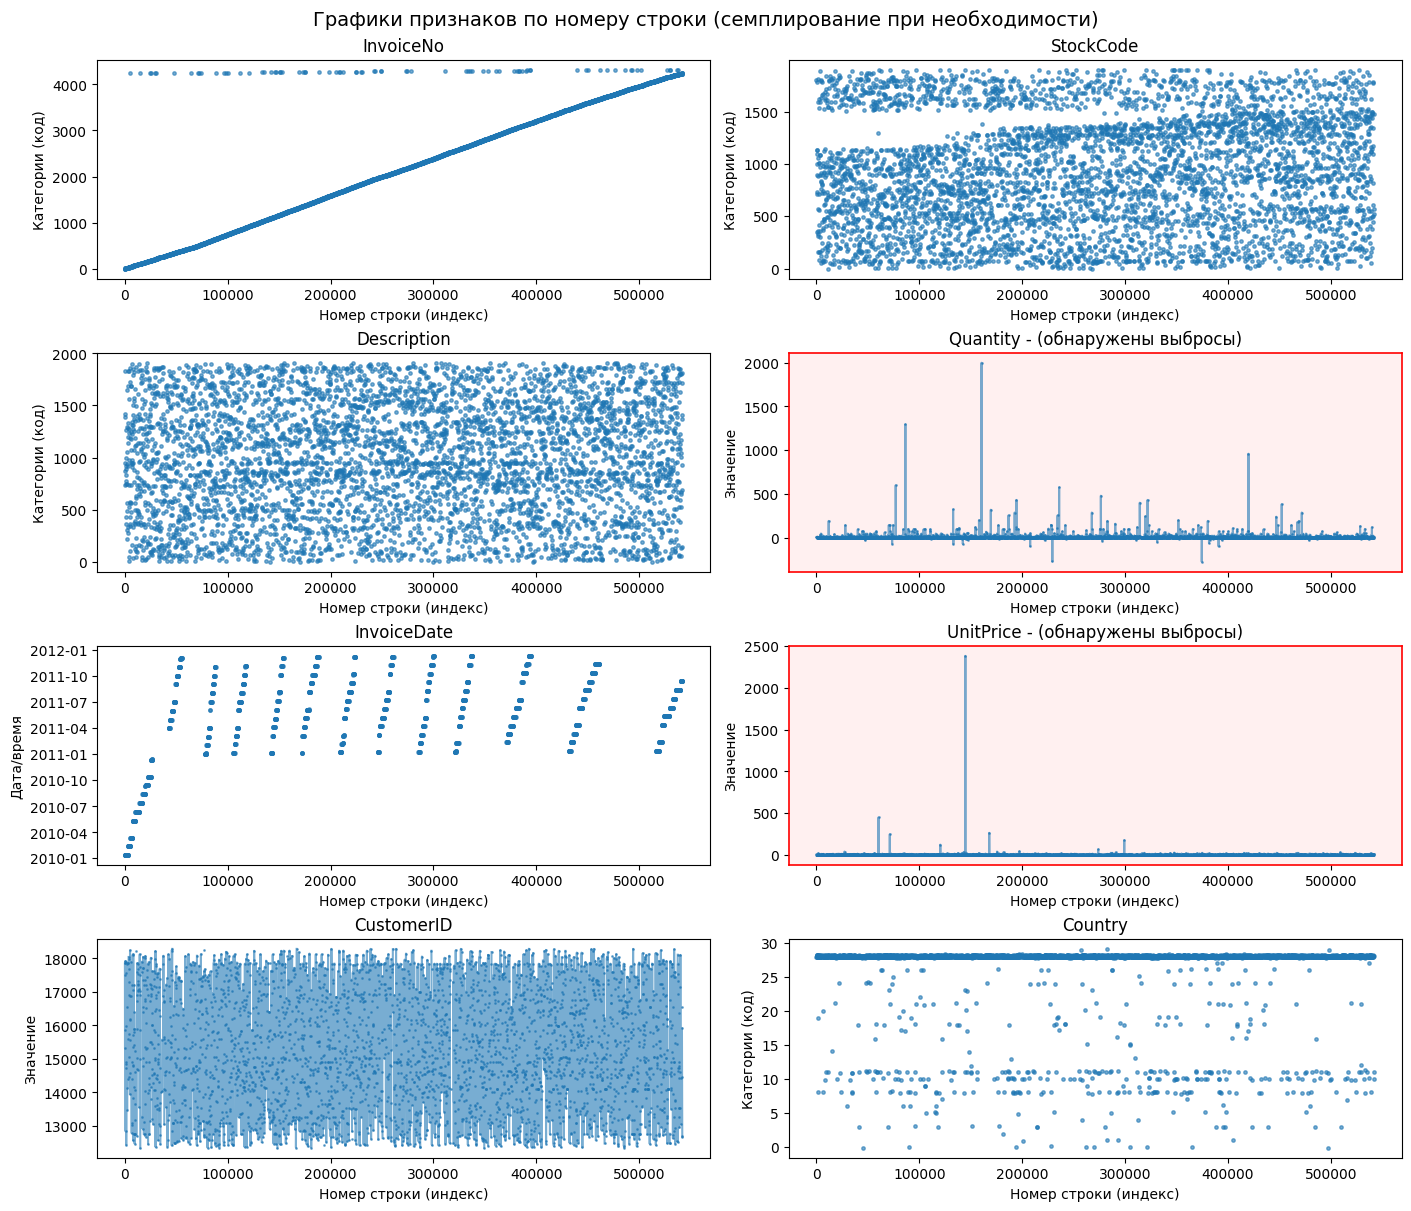

Краткая статистика по признакам:
- InvoiceNo: уникальных=4322, примеры=['536365' '536381' '536390' '536401' '536407']
- StockCode: уникальных=1902, примеры=['85123A' '22411' '22968' '85049E' '22632']
- Description: уникальных=1911, примеры=['WHITE HANGING HEART T-LIGHT HOLDER' 'JUMBO SHOPPER VINTAGE RED PAISLEY'
 'ROSE COTTAGE KEEPSAKE BOX ' 'SCANDINAVIAN REDS RIBBONS'
 'HAND WARMER RED POLKA DOT']
- Quantity: mean=10.383, std=45.447, min=-275, max=2000
- InvoiceDate: уникальных=4300, примеры=['01-12-2010 08:26' '01-12-2010 09:41' '01-12-2010 10:19'
 '01-12-2010 11:21' '01-12-2010 11:34']
- UnitPrice: mean=3.954, std=34.917, min=0.0, max=2382.92
- CustomerID: mean=15291.372, std=1714.086, min=12347.0, max=18287.0
- Country: уникальных=30, примеры=['United Kingdom' 'Norway' 'EIRE' 'Poland' 'France']


In [4]:

# Параметр: максимальное число точек для рисования (измените при необходимости)
max_points = 5000

retail_df_visualization = retail_df.copy()
n = len(retail_df_visualization)
print(f'Всего строк в датасете: {n}')

# Если слишком много строк, равномерно семплируем индексы, чтобы увидеть общую структуру
if n > max_points:
    sample_idx = np.linspace(0, n - 1, max_points, dtype=int)
    sampled = retail_df_visualization.iloc[sample_idx].reset_index(drop=True)
    x_vals = sample_idx
    print(f'Семплировано {max_points} точек (равномерно).')
else:
    sampled = retail_df_visualization.reset_index(drop=True)
    x_vals = sampled.index.values

# Попробуем корректно распарсить дату, если есть столбец InvoiceDate
if 'InvoiceDate' in sampled.columns:
    sampled['InvoiceDate_parsed'] = pd.to_datetime(sampled['InvoiceDate'], errors='coerce')

cols = [c for c in sampled.columns if not c.startswith('InvoiceDate_parsed')]
n_cols = len(cols)

# Список признаков, требующих внимания — укажите свои
attention_cols = {'Quantity', 'UnitPrice'}  # <- настройте

# Цвет подсветки и параметры
highlight_bg = '#fff0f0'   # светло-розовый фон для тревожных графиков
highlight_edge = 'red'
annotation_text = 'обнаружены выбросы'

# Настройка сетки под графики: 2 столбца, строки по числу признаков
ncols_plot = 2
nrows_plot = math.ceil(n_cols / ncols_plot)
figsize = (14, 3 * nrows_plot)
fig, axes = mpl_plt.subplots(nrows_plot, ncols_plot, figsize=figsize, constrained_layout=True)
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    ser = sampled[col]
    
    # Если признак помечен для внимания — меняем фон и рамку
    is_attention = col in attention_cols
    if is_attention:
        ax.set_facecolor(highlight_bg)
        for spine in ax.spines.values():
            spine.set_edgecolor(highlight_edge)
            spine.set_linewidth(1.2)

    # Если столбец — дата (мы создали parsed), используем parsed версию
    if col == 'InvoiceDate' and 'InvoiceDate_parsed' in sampled.columns:
        y = sampled['InvoiceDate_parsed']
        # рисуем как точечный график времени по номеру строки
        ax.scatter(x_vals, y, s=6, alpha=0.6)
        ax.set_ylabel('Дата/время')
    else:
        # Для числовых типов — прямая отрисовка, для категорий — факторизация
        if pd.api.types.is_numeric_dtype(ser):
            ax.plot(x_vals, ser.values, linestyle='-', marker='.', markersize=2, alpha=0.6)
            ax.set_ylabel('Значение')
        else:
            # факторизуем категориальные значения в коды для отображения
            codes, uniques = pd.factorize(ser, sort=True)
            # Заменим код -1 (для NaN) на np.nan чтобы не мешался
            codes = np.where(codes == -1, np.nan, codes)
            # Добавим немного шума, чтобы точки не наслаивались полностью
            jitter = np.random.normal(scale=0.08, size=len(codes))
            ax.scatter(x_vals, codes + (jitter if len(codes)==len(jitter) else 0), s=6, alpha=0.6)
            ax.set_ylabel('Категории (код)')
            # Если немного уникальных значений, подпишем ось Y метками
            if len(uniques) <= 20:
                ticks = np.arange(len(uniques))
                ax.set_yticks(ticks)
                ax.set_yticklabels([str(u) for u in uniques], fontsize=8)
    
    title = f'{col}'
    if is_attention:
        title += f' - ({annotation_text})'
    ax.set_title(title)
    ax.set_xlabel('Номер строки (индекс)')

# Если графиков меньше ячеек, уберём пустые
for j in range(n_cols, len(axes)):
    try:
        fig.delaxes(axes[j])
    except Exception:
        pass

mpl_plt.suptitle('Графики признаков по номеру строки (семплирование при необходимости)', fontsize=14)
mpl_plt.show()

# Дополнительно: вывести распределения/базовую статистику по каждому признаку (коротко)
print('Краткая статистика по признакам:')
for col in cols:
    ser = sampled[col]
    if pd.api.types.is_numeric_dtype(ser):    
        print(f'- {col}: mean={ser.mean():.3f}, std={ser.std():.3f}, min={ser.min()}, max={ser.max()}')
    else:        
        print(f'- {col}: уникальных={ser.nunique(dropna=True)}, примеры={ser.dropna().unique()[:5]}') 

del retail_df_visualization

#### Подготовка данных

In [5]:
# Создаем копию датасета для работы с выбросами
retail_df_outliers = retail_df.copy()

# Определяем признаки для анализа
numeric_cols = ['Quantity', 'UnitPrice']

print("\n1. Предварительный анализ числовых признаков:")
print("-" * 60)
for col in numeric_cols:
    print(f"\n{col}:")
    print(f"  Минимум: {retail_df_outliers[col].min()}")
    print(f"  Максимум: {retail_df_outliers[col].max()}")
    print(f"  Среднее: {retail_df_outliers[col].mean():.2f}")
    print(f"  Медиана: {retail_df_outliers[col].median():.2f}")
    print(f"  Стандартное отклонение: {retail_df_outliers[col].std():.2f}")
    print(f"  Отрицательных значений: {(retail_df_outliers[col] < 0).sum()}")
    print(f"  Нулевых значений: {(retail_df_outliers[col] == 0).sum()}")

# Статистика по выбросам
display(retail_df_outliers[numeric_cols].describe())


1. Предварительный анализ числовых признаков:
------------------------------------------------------------

Quantity:
  Минимум: -80995
  Максимум: 80995
  Среднее: 9.55
  Медиана: 3.00
  Стандартное отклонение: 218.08
  Отрицательных значений: 10624
  Нулевых значений: 0

UnitPrice:
  Минимум: -11062.06
  Максимум: 38970.0
  Среднее: 4.61
  Медиана: 2.08
  Стандартное отклонение: 96.76
  Отрицательных значений: 2
  Нулевых значений: 2515


,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


#### Удаление отрицательных значений

In [6]:
# Определяем числовые признаки для проверки
numeric_cols = ['Quantity', 'UnitPrice']

# Вычисляем медианные значения для каждого признака (только для положительных значений)
print("\nМедианные значения (по положительным значениям):")
medians = {}
for col in numeric_cols:
    # Вычисляем медиану только для положительных значений
    positive_values = retail_df_outliers[retail_df_outliers[col] >= 0][col]
    median_val = positive_values.median()
    medians[col] = median_val
    print(f"  {col}: медиана = {median_val:.2f}")

# Подсчитываем отрицательные значения по каждому признаку до замены
print("\nОтрицательные значения по признакам (до замены):")
for col in numeric_cols:
    negative_count = (retail_df_outliers[col] < 0).sum()
    print(f"  {col}: {negative_count} отрицательных значений")

# Заменяем отрицательные значения на медианные
print("\nВыполняется замена отрицательных значений...")
for col in numeric_cols:
    mask_negative = retail_df_outliers[col] < 0
    negative_count = mask_negative.sum()
    if negative_count > 0:
        retail_df_outliers.loc[mask_negative, col] = medians[col]
        print(f"  {col}: заменено {negative_count} значений на медиану ({medians[col]:.2f})")

# Проверяем результат
print("\nПроверка после замены:")
print("-" * 60)
for col in numeric_cols:
    negative_count = (retail_df_outliers[col] < 0).sum()
    print(f"  {col}: отрицательных значений = {negative_count}")
    print(f"    Минимум: {retail_df_outliers[col].min()}")
    print(f"    Максимум: {retail_df_outliers[col].max()}")
    print(f"    Медиана: {retail_df_outliers[col].median():.2f}")

# Выводим обновленную статистику
print("\nОбновленная статистика по числовым признакам:")
display(retail_df_outliers[numeric_cols].describe())



Медианные значения (по положительным значениям):
  Quantity: медиана = 3.00
  UnitPrice: медиана = 2.08

Отрицательные значения по признакам (до замены):
  Quantity: 10624 отрицательных значений
  UnitPrice: 2 отрицательных значений

Выполняется замена отрицательных значений...
  Quantity: заменено 10624 значений на медиану (3.00)
  UnitPrice: заменено 2 значений на медиану (2.08)

Проверка после замены:
------------------------------------------------------------
  Quantity: отрицательных значений = 0
    Минимум: 1
    Максимум: 80995
    Медиана: 3.00
  UnitPrice: отрицательных значений = 0
    Минимум: 0.0
    Максимум: 38970.0
    Медиана: 2.08

Обновленная статистика по числовым признакам:


,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,10.505183,4.651948
std,155.289026,94.395273
min,1.000000,0.000000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


#### Ограничение положительных выбросов по процентилям


In [7]:
print("\nВычисление процентилей и медианы:")
print("-" * 60)
percentiles = {}
medians = {}

for col in numeric_cols:
    # Вычисляем 95% процентили
    p95 = retail_df_outliers[col].quantile(0.95)
    median_val = retail_df_outliers[col].median()
    
    percentiles[col] = {'p95': p95}
    medians[col] = median_val
    
    print(f"\n{col}:")
    print(f"  95% процентиль: {p95:.2f}")
    print(f"  Медиана: {median_val:.2f}")

# Подсчитываем выбросы до обработки
print("\nВыбросы до обработки:")
print("-" * 60)
for col in numeric_cols:
    p95 = percentiles[col]['p95']
    
    # Находим значения, выходящие за пределы 95%
    outliers_high = (retail_df_outliers[col] > p95).sum()
    
    print(f"\n{col}:")
    print(f"  Значений > 95% процентиля ({p95:.2f}): {outliers_high}")

# Ограничиваем выбросы
print("\nВыполняется ограничение выбросов...")
print("-" * 60)

for col in numeric_cols:
    p95 = percentiles[col]['p95']
    
    # Для Quantity: заменяем на граничное значение (95% процентиль)
    if col == 'Quantity':
        # Значения больше 95% процентиля заменяем на 95% процентиль
        mask_high = retail_df_outliers[col] > p95
        count_high = mask_high.sum()
        if count_high > 0:
            retail_df_outliers.loc[mask_high, col] = p95
            print(f"  {col}: заменено {count_high} значений > 95% на {p95:.2f}")
    
    # Для UnitPrice: заменяем на медианное значение
    elif col == 'UnitPrice':
        median_val = medians[col]
        
        # Значения больше 95% процентиля заменяем на медиану
        mask_high = retail_df_outliers[col] > p95
        count_high = mask_high.sum()
        if count_high > 0:
            retail_df_outliers.loc[mask_high, col] = median_val
            print(f"  {col}: заменено {count_high} значений > 95% на медиану ({median_val:.2f})")

# Проверяем результат
print("\nПроверка после ограничения выбросов:")
print("=" * 60)
for col in numeric_cols:
    p95 = percentiles[col]['p95']

    outliers_high = (retail_df_outliers[col] > p95).sum()
    
    print(f"\n{col}:")
    print(f"  Значений > 95% процентиля: {outliers_high}")
    print(f"  Минимум: {retail_df_outliers[col].min():.2f}")
    print(f"  Максимум: {retail_df_outliers[col].max():.2f}")
    print(f"  Медиана: {retail_df_outliers[col].median():.2f}")

# Выводим обновленную статистику
print("\nОбновленная статистика по числовым признакам:")
display(retail_df_outliers[numeric_cols].describe())


Вычисление процентилей и медианы:
------------------------------------------------------------

Quantity:
  95% процентиль: 29.00
  Медиана: 3.00

UnitPrice:
  95% процентиль: 9.95
  Медиана: 2.08

Выбросы до обработки:
------------------------------------------------------------

Quantity:
  Значений > 95% процентиля (29.00): 27043

UnitPrice:
  Значений > 95% процентиля (9.95): 25620

Выполняется ограничение выбросов...
------------------------------------------------------------
  Quantity: заменено 27043 значений > 95% на 29.00
  UnitPrice: заменено 25620 значений > 95% на медиану (2.08)

Проверка после ограничения выбросов:

Quantity:
  Значений > 95% процентиля: 0
  Минимум: 1.00
  Максимум: 29.00
  Медиана: 3.00

UnitPrice:
  Значений > 95% процентиля: 0
  Минимум: 0.00
  Максимум: 9.95
  Медиана: 2.08

Обновленная статистика по числовым признакам:


,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,6.959227,2.673007
std,7.908242,2.131798
min,1.000000,0.000000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,3.750000
max,29.000000,9.950000


#### Визуализация обработанных данных

In [8]:
def plot_feature_boxplots_by_bins(df, features, n_bins=10):
    """
    Визуализирует boxplot каждого признака из списка features по диапазонам (bins) строк датафрейма.
    
    :param df: DataFrame с данными.
    :param features: Список названий числовых признаков, которые будут визуализированы.
    :param n_bins: Количество бинов для разбиения по строкам (по умолчанию 10).
    """
    n = len(df)
    bin_edges = np.linspace(0, n, n_bins + 1, dtype=int)
    for feature in features:
        box_data = []
        for i in range(n_bins):
            start_idx = bin_edges[i]
            end_idx = bin_edges[i+1]
            box_data.append(df[feature].iloc[start_idx:end_idx].values)

        mpl_plt.figure(figsize=(10, 4))
        mpl_plt.boxplot(box_data, positions=range(1, n_bins+1), showfliers=True, patch_artist=True)
        mpl_plt.title(f'Boxplot по диапазонам (bins) для {feature}')
        mpl_plt.xlabel('Бин (номер диапазона по строкам)')
        mpl_plt.ylabel(feature)
        mpl_plt.xticks(range(1, n_bins+1), [f'{bin_edges[i]}' for i in range(n_bins)])
        mpl_plt.grid(axis='y')
        mpl_plt.tight_layout()
        mpl_plt.show()

##### До обработки

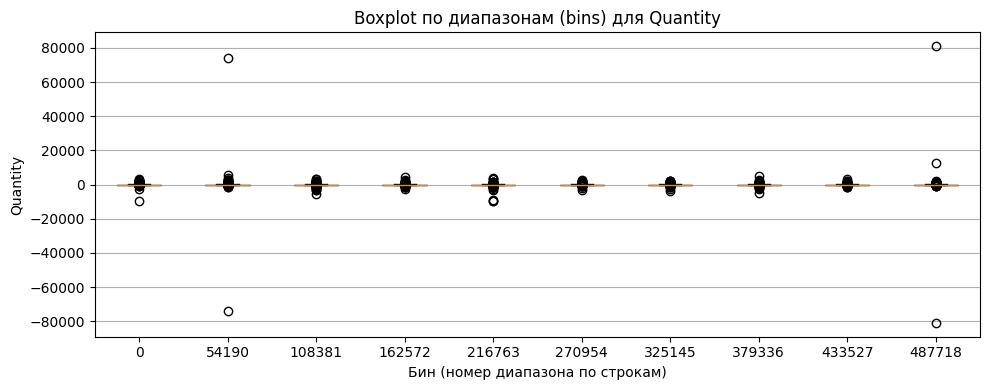

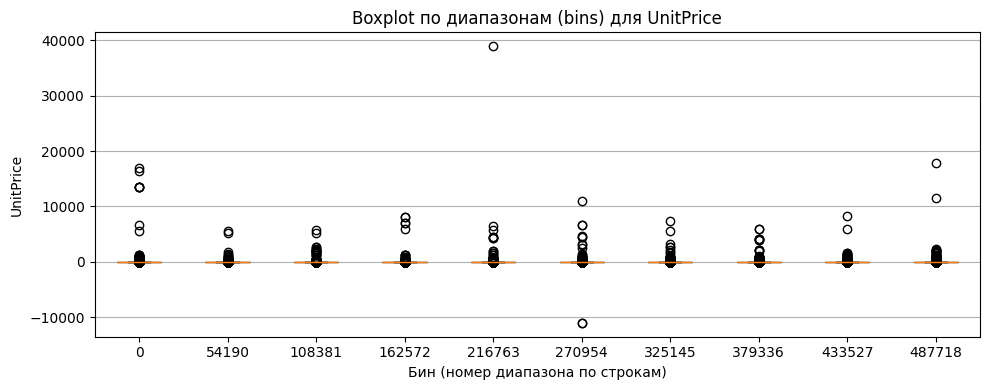

In [9]:
plot_feature_boxplots_by_bins(retail_df, attention_cols)

##### После обработки

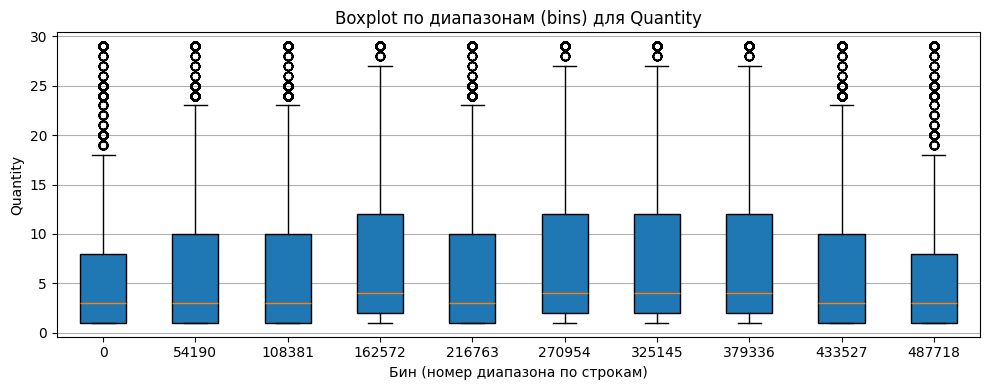

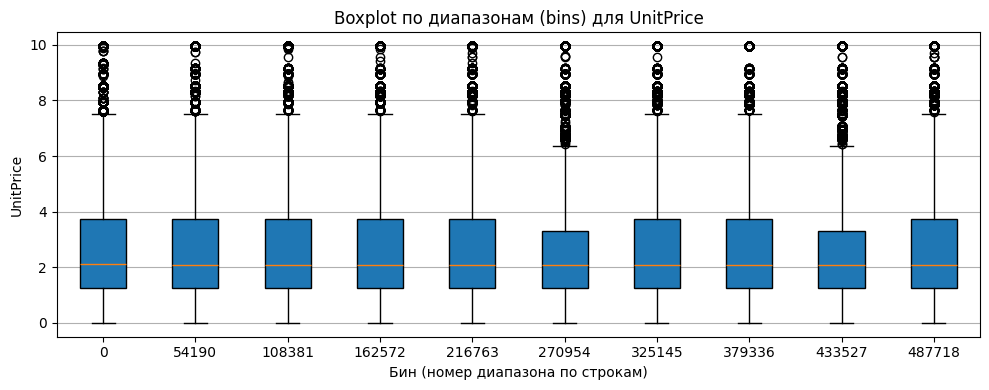

In [10]:
plot_feature_boxplots_by_bins(retail_df_outliers, attention_cols)

## Задание 3

### Формулировка

* Обработать  пропущенные  значения, подобрав 
подходящий алгоритм.

### Решение

#### Анализ пропущенных значений

Сначала проанализируем, какие признаки содержат пропущенные значения и в каком количестве.

In [11]:
print("Анализ пропущенных значений:")
print("=" * 60)

retail_df_empy_vall = retail_df_outliers.copy()

missing_analysis = pd.DataFrame({
    'Количество пропусков': retail_df_empy_vall.isnull().sum(),
    'Процент пропусков': (retail_df_empy_vall.isnull().sum() / len(retail_df_empy_vall) * 100).round(2),
    'Количество заполненных': retail_df_empy_vall.notna().sum()
})
missing_analysis = missing_analysis[missing_analysis['Количество пропусков'] > 0].sort_values('Количество пропусков', ascending=False)

display(missing_analysis)

# Проверим, пересекаются ли пропуски
print("\n2. Анализ пересечения пропусков:")
both_missing = retail_df_empy_vall[retail_df_empy_vall['Description'].isnull() & retail_df_empy_vall['CustomerID'].isnull()]
print(f"   Строк с пропусками в обоих признаках: {len(both_missing)}")

# Примеры строк с пропусками
print("\n3. Примеры строк с пропущенными значениями:")
mask = retail_df_empy_vall.isnull().any(axis=1)
display(retail_df_empy_vall.loc[mask].head(10))


Анализ пропущенных значений:


,Количество пропусков,Процент пропусков,Количество заполненных
CustomerID,135080,24.93,406829
Description,1454,0.27,540455



2. Анализ пересечения пропусков:
   Строк с пропусками в обоих признаках: 1454

3. Примеры строк с пропущенными значениями:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,29,01-12-2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,01-12-2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,01-12-2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,01-12-2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,01-12-2010 14:32,1.66,NaN,United Kingdom
1447,536544,21790,VINTAGE SNAP CARDS,9,01-12-2010 14:32,1.66,NaN,United Kingdom
1448,536544,21791,VINTAGE HEADS AND TAILS CARD GAME,2,01-12-2010 14:32,2.51,NaN,United Kingdom
1449,536544,21801,CHRISTMAS TREE DECORATION WITH BELL,10,01-12-2010 14:32,0.43,NaN,United Kingdom
1450,536544,21802,CHRISTMAS TREE HEART DECORATION,9,01-12-2010 14:32,0.43,NaN,United Kingdom
1451,536544,21803,CHRISTMAS TREE STAR DECORATION,11,01-12-2010 14:32,0.43,NaN,United Kingdom


#### Выбор алгоритма обработки пропущенных значений

**Обоснование выбора стратегии:**

1. **Description (Описание товара)** - ~0.27% пропусков:
   - **Стратегия:** Заполнение по StockCode (каталожному артикулу)
   - **Обоснование:** 
     - Описание товара тесно связано с его артикулом (StockCode)
     - Один и тот же артикул должен иметь одинаковое описание
     - Можно использовать наиболее частое описание для данного StockCode
     - Если для StockCode нет описания, используем сам StockCode как описание
   - **Алгоритм:** `fillna()` с группировкой по StockCode и применением `mode()` или `first()`

2. **CustomerID (Идентификатор клиента)** - ~24.9% пропусков:
   - **Стратегия:** Создание специальной категории для анонимных клиентов
   - **Обоснование:**
     - Большой процент пропусков (почти 25%) указывает на систематический характер (возможно, анонимные покупки)
     - CustomerID - категориальный идентификатор, его нельзя интерполировать
     - Заполнение средним/медианой не имеет смысла для идентификатора
     - Создание отдельной категории (например, 0 или -1) позволит сохранить информацию о наличии пропуска
   - **Алгоритм:** `fillna()` с специальным значением (0 или -1) с последующим преобразованием в категориальный тип


In [12]:
print("Обработка пропущенных значений:")
print("=" * 60)

# 1. Обработка Description
print("\n1. Обработка Description (Описание товара):")
print(f"   Пропусков до обработки: {retail_df_empy_vall['Description'].isnull().sum()}")

# Заполняем пропуски Description на основе StockCode
# Для каждого StockCode находим наиболее частое описание
stockcode_to_description = retail_df_empy_vall.groupby('StockCode')['Description'].apply(
    lambda x: x.mode().iloc[0] if not x.mode().empty else None
).to_dict()

# Заполняем пропуски
def fill_description(row):
    if pd.isna(row['Description']):
        stock_code = row['StockCode']
        if stock_code in stockcode_to_description and stockcode_to_description[stock_code] is not None:
            return stockcode_to_description[stock_code]
        else:
            # Если для StockCode нет описания, используем сам StockCode
            return f"Unknown Item ({stock_code})"
    return row['Description']

retail_df_empy_vall['Description'] = retail_df_empy_vall.apply(fill_description, axis=1)

print(f"   Пропусков после обработки: {retail_df_empy_vall['Description'].isnull().sum()}")

# 2. Обработка CustomerID
print("\n2. Обработка CustomerID (Идентификатор клиента):")
print(f"   Пропусков до обработки: {retail_df_empy_vall['CustomerID'].isnull().sum()}")

# Заполняем пропуски специальным значением для анонимных клиентов
# Используем 0 как идентификатор анонимного клиента
retail_df_empy_vall['CustomerID'] = retail_df_empy_vall['CustomerID'].fillna(0)

# Преобразуем в целочисленный тип (так как это идентификатор)
retail_df_empy_vall['CustomerID'] = retail_df_empy_vall['CustomerID'].astype(int)

print(f"   Пропусков после обработки: {retail_df_empy_vall['CustomerID'].isnull().sum()}")

# Проверка результата
print("\n" + "=" * 60)
print("Итоговая проверка пропущенных значений:")
print("=" * 60)
final_missing = retail_df_empy_vall.isnull().sum()
final_missing = final_missing[final_missing > 0]
if len(final_missing) == 0:
    print("✓ Все пропущенные значения успешно обработаны!")
else:
    print("Остались пропуски в следующих признаках:")
    display(final_missing)

print("\nИнформация о датасете после обработки:")
retail_df_empy_vall.info()


Обработка пропущенных значений:

1. Обработка Description (Описание товара):
   Пропусков до обработки: 1454
   Пропусков после обработки: 0

2. Обработка CustomerID (Идентификатор клиента):
   Пропусков до обработки: 135080
   Пропусков после обработки: 0

Итоговая проверка пропущенных значений:
✓ Все пропущенные значения успешно обработаны!

Информация о датасете после обработки:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  541909 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   541909 non-null  int64  
 7   Country      541909 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 33.1+ MB


#### Визуализация результатов обработки

Проверим качество обработки и покажем примеры заполненных значений.


In [13]:

# 1. Сравнение до и после обработки
comparison = pd.DataFrame({
    'До обработки': [retail_df['Description'].isnull().sum(), retail_df['CustomerID'].isnull().sum()],
    'После обработки': [retail_df_empy_vall['Description'].isnull().sum(), retail_df_empy_vall['CustomerID'].isnull().sum()]
}, index=['Description', 'CustomerID'])

print("Сравнение количества пропусков до и после обработки:")
display(comparison)

# 2. Примеры заполненных значений Description
print("\nПримеры заполненных значений Description:")
# Найдем строки, где Description был заполнен
original_missing_desc = retail_df['Description'].isnull()
filled_desc = retail_df_empy_vall[original_missing_desc][['StockCode', 'Description']].head(10)
display(filled_desc)

# 3. Статистика по CustomerID
print("\nСтатистика по CustomerID:")
cust_stats = pd.DataFrame({
    'Категория': ['Идентифицированные клиенты', 'Анонимные клиенты (CustomerID=0)'],
    'Количество транзакций': [
        (retail_df_empy_vall['CustomerID'] != 0).sum(),
        (retail_df_empy_vall['CustomerID'] == 0).sum()
    ],
    'Процент': [
        (retail_df_empy_vall['CustomerID'] != 0).sum() / len(retail_df_empy_vall) * 100,
        (retail_df_empy_vall['CustomerID'] == 0).sum() / len(retail_df_empy_vall) * 100
    ]
})
display(cust_stats)

Сравнение количества пропусков до и после обработки:


,До обработки,После обработки
Description,1454,0
CustomerID,135080,0



Примеры заполненных значений Description:


,StockCode,Description
622,22139,RETROSPOT TEA SET CERAMIC 11 PC
1970,21134,Unknown Item (21134)
1971,22145,CHRISTMAS CRAFT HEART STOCKING
1972,37509,NEW ENGLAND MUG W GIFT BOX
1987,85226A,Unknown Item (85226A)
1988,85044,Unknown Item (85044)
2024,20950,Unknown Item (20950)
2025,37461,FUNKY MONKEY MUG
2026,84670,Unknown Item (84670)
2406,21777,RECIPE BOX WITH METAL HEART



Статистика по CustomerID:


,Категория,Количество транзакций,Процент
0,Идентифицированные клиенты,406829,75.073306
1,Анонимные клиенты (CustomerID=0),135080,24.926694


## Задание 4

### Формулировка

* Выполнить  преобразование  категориальных  данных 
(при наличии), подобрав подходящие алгоритмы.

In [14]:
# Создаем копию датасета для преобразования категориальных данных
retail_df_categorical = retail_df_empy_vall.copy()

print(f"\nИсходная информация о датасете:")
retail_df_categorical.info()


Исходная информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  541909 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   541909 non-null  int64  
 7   Country      541909 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 33.1+ MB


### Решение

#### 1. Преобразование InvoiceNo: разделение на InvoiceNo (число) и InvoiceType (префикс)


In [15]:
print("\n1. Преобразование InvoiceNo:")
print("-" * 60)

# Анализируем структуру InvoiceNo
print("Примеры значений InvoiceNo:")
sample_invoices = retail_df_categorical['InvoiceNo'].unique()[:20]
print(sample_invoices)

# Проверяем, есть ли значения с префиксами (не только цифры)
has_prefix = retail_df_categorical['InvoiceNo'].str.contains(r'^[A-Za-z]', regex=True, na=False)
print(f"\nКоличество значений с префиксом (буквы): {has_prefix.sum()}")
print(f"Примеры значений с префиксом:")
display(retail_df_categorical[has_prefix]['InvoiceNo'].unique()[:10])

# Разделяем InvoiceNo на числовую часть и префикс
def split_invoice_no(invoice_str):
    """Разделяет InvoiceNo на префикс и числовую часть"""
    if pd.isna(invoice_str):
        return None, None
    
    invoice_str = str(invoice_str)
    # Ищем префикс (все нецифровые символы в начале)
    match = re.match(r'^([A-Za-z]*)(\d+)$', invoice_str)
    if match:
        prefix = match.group(1) if match.group(1) else ''
        number = int(match.group(2))
        return prefix, number
    else:
        # Если не удалось распарсить, возвращаем как есть
        return '', int(invoice_str) if invoice_str.isdigit() else 0

# Применяем функцию разделения
invoice_parts = retail_df_categorical['InvoiceNo'].apply(split_invoice_no)

retail_df_categorical['InvoiceType'] = invoice_parts.apply(lambda x: x[0] if x[0] else '-')
retail_df_categorical['InvoiceNo_num'] = invoice_parts.apply(lambda x: x[1] if x[1] is not None else 0)

# Удаляем исходный столбец InvoiceNo и переименовываем новый
retail_df_categorical = retail_df_categorical.drop(columns=['InvoiceNo'])
retail_df_categorical = retail_df_categorical.rename(columns={'InvoiceNo_num': 'InvoiceNo'})

# Преобразуем InvoiceNo в int
retail_df_categorical['InvoiceNo'] = retail_df_categorical['InvoiceNo'].astype(int)

print("\nРезультат преобразования:")
print(f"Уникальных типов InvoiceType: {retail_df_categorical['InvoiceType'].nunique()}")
print(f"Распределение InvoiceType:")
value_counts = retail_df_categorical['InvoiceType'].value_counts()

print("\nПримеры данных после преобразования:")
for invoice_type in value_counts.index:
    print(f"примеры с типом : {invoice_type}")
    mask = retail_df_categorical['InvoiceType'] == invoice_type
    display(retail_df_categorical[mask][['InvoiceNo', 'InvoiceType']].head())



1. Преобразование InvoiceNo:
------------------------------------------------------------
Примеры значений InvoiceNo:
['536365' '536366' '536367' '536368' '536369' '536370' '536371' '536372'
 '536373' '536374' '536375' '536376' '536377' '536378' '536380' '536381'
 'C536379' '536382' 'C536383' '536384']

Количество значений с префиксом (буквы): 9291
Примеры значений с префиксом:


array(['C536379', 'C536383', 'C536391', 'C536506', 'C536543', 'C536548',
       'C536606', 'C536622', 'C536625', 'C536642'], dtype=object)


Результат преобразования:
Уникальных типов InvoiceType: 3
Распределение InvoiceType:

Примеры данных после преобразования:
примеры с типом : -


,InvoiceNo,InvoiceType
0,536365,-
1,536365,-
2,536365,-
3,536365,-
4,536365,-


примеры с типом : C


,InvoiceNo,InvoiceType
141,536379,C
154,536383,C
235,536391,C
236,536391,C
237,536391,C


примеры с типом : A


,InvoiceNo,InvoiceType
299982,563185,A
299983,563186,A
299984,563187,A


Дополнительно: кодируем InvoiceType с помощью Label Encoding

In [16]:
invoice_type_encoder = LabelEncoder()
retail_df_categorical['InvoiceType_encoded'] = invoice_type_encoder.fit_transform(retail_df_categorical['InvoiceType'])

# Заменяем исходный InvoiceType на закодированный
retail_df_categorical = retail_df_categorical.drop(columns=['InvoiceType'])
retail_df_categorical = retail_df_categorical.rename(columns={'InvoiceType_encoded': 'InvoiceType'})

print("InvoiceType закодирован:")
print(f"Соответствие исходных значений и кодов:")
invoice_type_mapping = pd.DataFrame({
    'Исходное значение': invoice_type_encoder.classes_,
    'Код': range(len(invoice_type_encoder.classes_))
})
display(invoice_type_mapping)


InvoiceType закодирован:
Соответствие исходных значений и кодов:


,Исходное значение,Код
0,-,0
1,A,1
2,C,2


In [17]:
value_counts = retail_df_categorical['InvoiceType'].value_counts()

print("\nПримеры данных после преобразования:")
for invoice_type in value_counts.index:
    print(f"примеры с типом : {invoice_type}")
    mask = retail_df_categorical['InvoiceType'] == invoice_type
    display(retail_df_categorical[mask][['InvoiceNo', 'InvoiceType']].head())


Примеры данных после преобразования:
примеры с типом : 0


,InvoiceNo,InvoiceType
0,536365,0
1,536365,0
2,536365,0
3,536365,0
4,536365,0


примеры с типом : 2


,InvoiceNo,InvoiceType
141,536379,2
154,536383,2
235,536391,2
236,536391,2
237,536391,2


примеры с типом : 1


,InvoiceNo,InvoiceType
299982,563185,1
299983,563186,1
299984,563187,1


#### 2. Преобразование StockCode: Label Encoding


In [18]:
# Создаем кодировщик
stockcode_encoder = LabelEncoder()

# Применяем Label Encoding
retail_df_categorical['StockCode_encoded'] = stockcode_encoder.fit_transform(retail_df_categorical['StockCode'])

# Сохраняем исходный StockCode для справки (можно удалить позже)
print(f"Уникальных значений StockCode: {retail_df_categorical['StockCode'].nunique()}")
print(f"Диапазон закодированных значений: {retail_df_categorical['StockCode_encoded'].min()} - {retail_df_categorical['StockCode_encoded'].max()}")

print("\nПримеры преобразования:")
sample_stock = retail_df_categorical[['StockCode', 'StockCode_encoded']].head(10)
display(sample_stock)

# Заменяем исходный столбец на закодированный
retail_df_categorical = retail_df_categorical.drop(columns=['StockCode'])
retail_df_categorical = retail_df_categorical.rename(columns={'StockCode_encoded': 'StockCode'})


Уникальных значений StockCode: 4070
Диапазон закодированных значений: 0 - 4069

Примеры преобразования:


,StockCode,StockCode_encoded
0,85123A,3536
1,71053,2794
2,84406B,3044
3,84029G,2985
4,84029E,2984
5,22752,1662
6,21730,800
7,22633,1547
8,22632,1546
9,84879,3305


#### 3. Преобразование Description: хеширование


Обоснование использования хеширования:
- Description содержит текстовые описания товаров
- Большое количество уникальных значений (тысячи)
- Текстовые данные занимают много памяти
- Хеширование позволяет преобразовать строки в фиксированный размер (число)
- Сохраняет возможность группировки по одинаковым описаниям
- Уменьшает размер датасета в памяти

In [19]:
# Анализируем Description перед преобразованием
print(f"Уникальных значений Description: {retail_df_categorical['Description'].nunique()}")
print(f"Общее количество строк: {len(retail_df_categorical)}")
print(f"Средняя длина описания: {retail_df_categorical['Description'].str.len().mean():.1f} символов")


# Используем встроенную функцию hash() Python для хеширования
# Применяем хеширование к каждому описанию
retail_df_categorical['Description_hash'] = retail_df_categorical['Description'].apply(
    lambda x: hash(str(x)) if pd.notna(x) else hash('')
)

# Преобразуем в положительные числа (модуль хеша)
retail_df_categorical['Description_hash'] = retail_df_categorical['Description_hash'].abs()

# Проверяем коллизии (одинаковые хеши для разных описаний)
original_unique = retail_df_categorical['Description'].nunique()
hash_unique = retail_df_categorical['Description_hash'].nunique()
collisions = original_unique - hash_unique

print(f"Уникальных описаний: {original_unique}")
print(f"Уникальных хешей: {hash_unique}")
print(f"Коллизий (если есть): {collisions}")

# Заменяем исходный столбец на хешированный
retail_df_categorical = retail_df_categorical.drop(columns=['Description'])
retail_df_categorical = retail_df_categorical.rename(columns={'Description_hash': 'Description'})

print("\nПримеры преобразования (первые 10 строк):")
# Показываем примеры (но уже без исходного Description, так как он удален)
display(retail_df_categorical[['Description']].head(10))


Уникальных значений Description: 4335
Общее количество строк: 541909
Средняя длина описания: 26.6 символов
Уникальных описаний: 4335
Уникальных хешей: 4335
Коллизий (если есть): 0

Примеры преобразования (первые 10 строк):


,Description
0,4876266595196798137
1,7682174887846295162
2,7991104147856964695
3,7170512751899811234
4,2968674389100626174
5,4571012449455330439
6,4353515450897173874
7,4065738472273965985
8,6610285656903161591
9,6506104317757400538


#### 4. Преобразование Country: Label Encoding


In [20]:
# Создаем кодировщик для Country
from matplotlib.axes import Axes


country_encoder = LabelEncoder()

# Применяем Label Encoding
retail_df_categorical['Country_encoded'] = country_encoder.fit_transform(retail_df_categorical['Country'])

print(f"Уникальных значений Country: {retail_df_categorical['Country'].nunique()}")
print(f"Диапазон закодированных значений: {retail_df_categorical['Country_encoded'].min()} - {retail_df_categorical['Country_encoded'].max()}")

# Показываем соответствие между исходными значениями и кодами
country_mapping = pd.DataFrame({
    'Country': country_encoder.classes_,
    'Code': range(len(country_encoder.classes_))
})
print("\nСоответствие Country -> Code:")
display(country_mapping)

print("\nРаспределение по странам (топ-10):")
country_counts = retail_df_categorical['Country'].value_counts().head(10)
display(country_counts)

# Заменяем исходный столбец на закодированный
retail_df_categorical = retail_df_categorical.drop(columns=['Country'])
retail_df_categorical = retail_df_categorical.rename(columns={'Country_encoded': 'Country'})


Уникальных значений Country: 38
Диапазон закодированных значений: 0 - 37

Соответствие Country -> Code:


,Country,Code
0,Australia,0
1,Austria,1
2,Bahrain,2
3,Belgium,3
4,Brazil,4
5,Canada,5
6,Channel Islands,6
7,Cyprus,7
8,Czech Republic,8
9,Denmark,9



Распределение по странам (топ-10):


Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

#### Итоговая проверка преобразований


In [21]:
print("\nИнформация о датасете после всех преобразований:")

comparison_types = pd.DataFrame({
    'Столбец': retail_df_categorical.columns,
    'Тип данных': [str(dtype) for dtype in retail_df_categorical.dtypes]
})
display(comparison_types)

print("\nПервые 10 строк преобразованного датасета:")
display(retail_df_categorical.head(10))

print("\nСтатистика по признакам:")
display(retail_df_categorical.describe())

print("\n✓ Все преобразования категориальных данных выполнены успешно!")



Информация о датасете после всех преобразований:


,Столбец,Тип данных
0,Quantity,int64
1,InvoiceDate,object
2,UnitPrice,float64
3,CustomerID,int64
4,InvoiceNo,int64
5,InvoiceType,int64
6,StockCode,int64
7,Description,int64
8,Country,int64



Первые 10 строк преобразованного датасета:


,Quantity,InvoiceDate,UnitPrice,CustomerID,InvoiceNo,InvoiceType,StockCode,Description,Country
0,6,01-12-2010 08:26,2.55,17850,536365,0,3536,4876266595196798137,36
1,6,01-12-2010 08:26,3.39,17850,536365,0,2794,7682174887846295162,36
2,8,01-12-2010 08:26,2.75,17850,536365,0,3044,7991104147856964695,36
3,6,01-12-2010 08:26,3.39,17850,536365,0,2985,7170512751899811234,36
4,6,01-12-2010 08:26,3.39,17850,536365,0,2984,2968674389100626174,36
5,2,01-12-2010 08:26,7.65,17850,536365,0,1662,4571012449455330439,36
6,6,01-12-2010 08:26,4.25,17850,536365,0,800,4353515450897173874,36
7,6,01-12-2010 08:28,1.85,17850,536366,0,1547,4065738472273965985,36
8,6,01-12-2010 08:28,1.85,17850,536366,0,1546,6610285656903161591,36
9,29,01-12-2010 08:34,1.69,13047,536367,0,3305,6506104317757400538,36



Статистика по признакам:


,Quantity,UnitPrice,CustomerID,InvoiceNo,InvoiceType,StockCode,Description,Country
count,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000,5.419090e+05,541909.000000
mean,6.959227,2.673007,11476.974671,559946.967325,0.034284,1650.693107,4.736779e+18,34.259772
std,7.908242,2.131798,6777.908326,13421.287454,0.259592,932.806239,2.674897e+18,6.222861
min,1.000000,0.000000,0.000000,536365.000000,0.000000,0.000000,8.903172e+14,0.000000
25%,1.000000,1.250000,12352.000000,547896.000000,0.000000,966.000000,2.418240e+18,36.000000
50%,3.000000,2.080000,14382.000000,560601.000000,0.000000,1563.000000,4.851431e+18,36.000000
75%,10.000000,3.750000,16255.000000,571779.000000,0.000000,2174.000000,6.997450e+18,36.000000
max,29.000000,9.950000,18287.000000,581587.000000,2.000000,4069.000000,9.222249e+18,37.000000



✓ Все преобразования категориальных данных выполнены успешно!


## Задание 5

### Формулировка

* К временным данным следует применить квантование.

### Решение

В датасете соответствующему варианту #4 нет временн**ы**х данных, к которым имело бы смысл применять квантование.